In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.signal import chirp
from scipy.special import hyperu, laguerre, genlaguerre, hyp1f1
from scipy.constants import hbar
from scipy.constants import k as kB
from tqdm import tqdm
import dill
from scipy.integrate import quad
import qcontrol as qc

In [2]:
qargs = {
    'optical_fc':           2e9, 
    'optical_df':           0.3e9,
    'mw_fc':                1.3e9, 
    'optical_lifetime':     6e-9, 
    'branching_ratio':      0.0005,
    'dark_count_rate':      10e3,
    'coupling_efficiency':  0.01,
    'debye_waller_factor':  0.8,
    'quantum_efficiency': 0.6,
    }
q = qc.ColorCenterQubit(**qargs)
pulses = {
    'pi' : {
        'frequency' : q.mw_fc,
        'width' : 115e-9,
        't_ramp' : 10e-9,
        'amplitude' : 30.0e6
    },
    'pi/2' : {
        'frequency' : q.mw_fc,
        'width' : 62.5e-9,
        't_ramp' : 10e-9,
        'amplitude' : 30.0e6
    },
    'readout_down' : {
        'frequency' : q.f0,
        'width' : 60e-6,
        't_ramp' : 1e-6,
        'amplitude' : 3e8
    },
    'readout_up' : {
        'frequency' : q.f1,
        'width' : 60e-6,
        't_ramp' : 1e-6,
        'amplitude' : 3e8
    },
    'init_up' : {
        'frequency' : q.f0,
        'width' : 120e-6,
        't_ramp' : 1e-6,
        'amplitude' : 3e8
    },
    'single_photon' : {
        'frequency' : q.f0,
        'width' : 2e-6,
        't_ramp' : 1e-6,
        'amplitude' : 200
    },
    'init_fast' : {
        'frequency' : q.f1-q.f0+q.mw_fc,
        'width' : 120e-6,
        't_ramp' : 1e-6,
        'amplitude' : 30e6
    }
}



def process_pulse_train(t, pulse_sequence, local_pulses=pulses, plot=False):
    phase_flags = { '_X' : 0, '_Y' : np.pi/2, '_-X' : np.pi, '_-Y' : -np.pi/2}
    pulse_sigs = {}
    for channel, pulse_dict in pulse_sequence.items():
        pulse_sigs[channel] = np.zeros_like(t, dtype=complex)
        current_time = 0
        pulse_train = pulse_dict['pulse_train']
        for p in pulse_train:
            if isinstance(p, str):
                phase = 0
                for flag, phase_val in phase_flags.items():
                    if flag in p:
                        phase = phase_val
                        p = p.replace(flag, '')
                envelope = qc.tools.__smooth_square_pulse(None, t, current_time, local_pulses[p]['width'], local_pulses[p]['t_ramp'], local_pulses[p]['amplitude'])
                modulation = np.cos(2*np.pi*local_pulses[p]['frequency']*t+phase)
                pulse_sigs[channel] += envelope*modulation
                if plot:
                    plt.plot(t*1e6, envelope/np.max(envelope), label=f"{channel} Envelope")
                current_time += local_pulses[p]['width']
            else:
                current_time += p
    if plot:
        for channel, pulse_sig in pulse_sigs.items():
            plt.plot(t*1e6, pulse_sig/np.max(pulse_sig), label=channel)

        plt.legend()
        plt.xlabel('Time (us)')
        plt.ylabel('Pulse Amplitude')
        plt.title('Pulse Sequence')
        
    return pulse_sigs

def get_pulse_train_time(pulse_sequence, local_pulses=pulses):
    phase_flags = { '_X' : 0, '_Y' : np.pi/2, '_-X' : np.pi, '_-Y' : -np.pi/2}
    max_time = 0
    for channel, pulse_dict in pulse_sequence.items():
        current_time = 0
        pulse_train = pulse_dict['pulse_train']
        for p in pulse_train:
            if isinstance(p, str):
                phase = 0
                for flag, phase_val in phase_flags.items():
                    if flag in p:
                        phase = phase_val
                        p = p.replace(flag, '')
                current_time += local_pulses[p]['width']
            else:
                current_time += p
        max_time = max(max_time, current_time)
    return max_time


/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


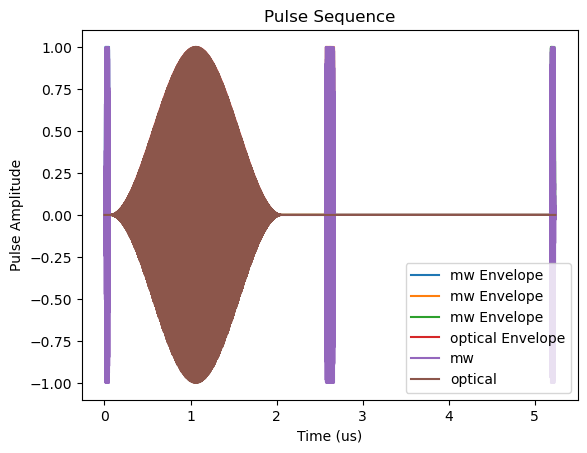

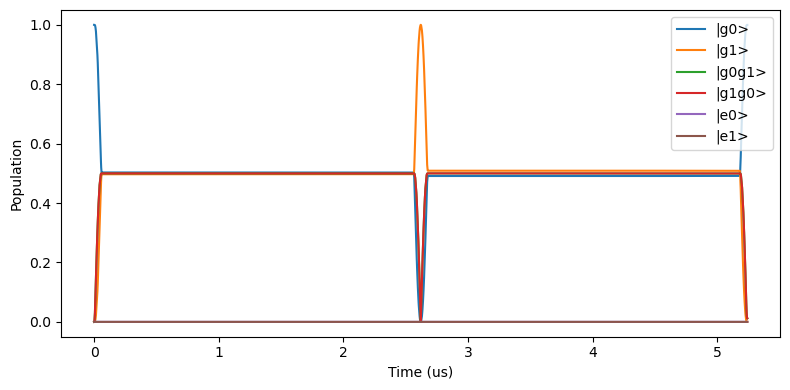

In [8]:

wait_time = 5e-6
transfer = []
ramsey_sequence = {
    'mw'      : {'pulse_train' : ['pi/2_X', wait_time/2, 'pi_X', wait_time/2, 'pi/2_X']},
    'optical' : {'pulse_train' : [pulses['pi/2']['width'],'single_photon']}
}
t = np.arange(0, get_pulse_train_time(ramsey_sequence), 1/6.144e9)
ramsey_sigs = process_pulse_train(t, ramsey_sequence, plot=True)   
q = qc.ColorCenterQubit(**qargs, psi0 = qt.basis(4,0).proj())
result = q.apply_pulse_sequence(t, ramsey_sigs, plot=True, custom_options={'atol':1e-9, 'rtol':1e-9})
    

In [4]:
amps = np.logspace(2, 8, 7)
widths = np.linspace(2e-6, 10e-6, 9)
print(amps, widths)

[1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08] [2.e-06 3.e-06 4.e-06 5.e-06 6.e-06 7.e-06 8.e-06 9.e-06 1.e-05]


100%|██████████| 210/210 [00:38<00:00,  5.45it/s]


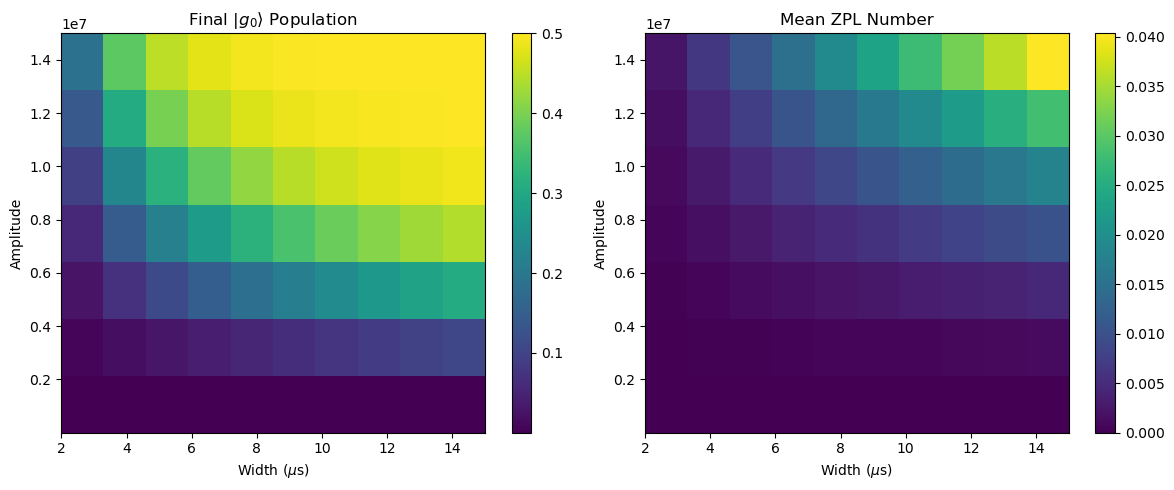

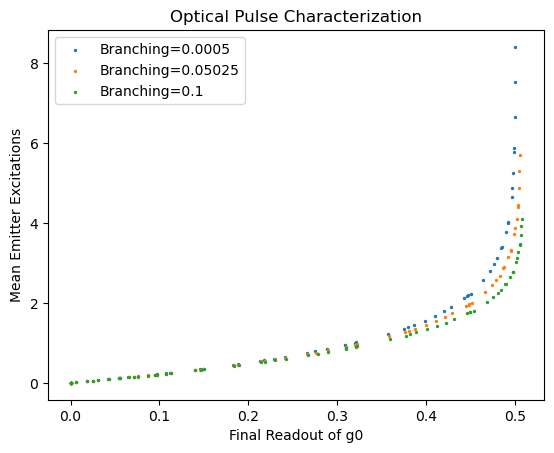

In [ ]:
import concurrent.futures
import copy
from tqdm import tqdm
amps = np.linspace(1e2, 1.5e7, 7)
widths = np.linspace(2e-6, 15e-6, 10)
branching_ratios = np.linspace(0.0005, 0.1, 3)
final_g0 = np.zeros((len(amps), len(widths), len(branching_ratios)))
mean_decay_number = np.zeros((len(amps), len(widths), len(branching_ratios)))
mean_zpl_counts = np.zeros((len(amps), len(widths), len(branching_ratios)))

def compute_single_point(args):
    amp_i, amp, w_i, width, b_i, br = args
    # The 'pulses' dictionary here must be per-thread; if it's global and thread-mutated, this could cause trouble.
    # Let's assume 'pulses' is a copy and not global state, or copy it in the thread.
    # Deepcopy pulses to avoid thread collisions if needed:
    local_pulses = {
        'pi' : {
            'frequency' : q.mw_fc,
            'width' : 115e-9,
            't_ramp' : 10e-9,
            'amplitude' : 30.0e6
        },
        'pi/2' : {
            'frequency' : q.mw_fc,
            'width' : 62.5e-9,
            't_ramp' : 10e-9,
            'amplitude' : 30.0e6
        },
        'single_photon' : {
            'frequency' : q.f0,
            'width' : width,
            't_ramp' : 1e-6,
            'amplitude' : amp
        }
    }
    qargs_local = {
    'optical_fc':           2e9, 
    'optical_df':           0.3e9,
    'mw_fc':                1.3e9, 
    'optical_lifetime':     6e-9, 
    'branching_ratio':      br,
    'dark_count_rate':      10e3,
    'coupling_efficiency':  0.01,
    'debye_waller_factor':  0.8,
    'quantum_efficiency': 0.6,
    }

    wait_time = width + 1e-6
    ramsey_sequence = {
        'mw'      : {'pulse_train' : ['pi/2_X', wait_time, 'pi_X', wait_time, 'pi/2_X']},
        'optical' : {'pulse_train' : [local_pulses['pi/2']['width'], 'single_photon']}
    }
    bin_dt = 1/6.144e9
    t = np.arange(0, get_pulse_train_time(ramsey_sequence, local_pulses=local_pulses), bin_dt)
    ramsey_sigs = process_pulse_train(t, ramsey_sequence, local_pulses=local_pulses, plot=False)   
    q_local = qc.ColorCenterQubit(**qargs_local, psi0 = qt.basis(4,1).proj())
    result_local = q_local.apply_pulse_sequence(t, ramsey_sigs, plot=False, custom_options={'atol':1e-9, 'rtol':1e-9})
    final_g0_val = result_local.expect[0][-1]
    mean_decay = np.sum(bin_dt*1/q_local.optical_lifetime*(result_local.expect[4] + result_local.expect[5]))
    mean_zpl = np.sum(q_local.process_result(result_local, bin_dt, 1, 1, use_dark_counts=False, cps=False)[0])
    return (amp_i, w_i, b_i, final_g0_val, mean_decay, mean_zpl)

# Prepare argument tuples
point_args = [(amp_i, amp, w_i, width, b_i, br) for amp_i, amp in enumerate(amps) for w_i, width in enumerate(widths) for b_i, br in enumerate(branching_ratios)]
results = []

with concurrent.futures.ProcessPoolExecutor() as executor:
    futures = [executor.submit(compute_single_point, args)
               for args in point_args]

    for future in tqdm(concurrent.futures.as_completed(futures), total=len(point_args)):
        try:
            results.append(future.result())
        except Exception as e:
            print("Point failed:", e)

for amp_i, w_i, b_i, g0_val, decay_num, zpl_num in results:
    final_g0[amp_i, w_i, b_i] = g0_val
    mean_decay_number[amp_i, w_i, b_i] = decay_num
    mean_zpl_counts[amp_i, w_i, b_i] = zpl_num

# Plot the results on subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot final_g0
im0 = axs[0].imshow(final_g0[:,:,0], aspect='auto', origin='lower', 
                    extent=[widths[0]*1e6, widths[-1]*1e6, amps[0], amps[-1]])
axs[0].set_title('Final $|g_0\\rangle$ Population')
axs[0].set_xlabel('Width ($\\mu$s)')
axs[0].set_ylabel('Amplitude')
fig.colorbar(im0, ax=axs[0])

# Plot mean_photon_number
im1 = axs[1].imshow(mean_zpl_counts[:,:,0], aspect='auto', origin='lower', 
                    extent=[widths[0]*1e6, widths[-1]*1e6, amps[0], amps[-1]])
axs[1].set_title('$n_{detections}$')
axs[1].set_xlabel('Width ($\\mu$s)')
axs[1].set_ylabel('Amplitude')
fig.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()

plt.figure()
for b_i, br in enumerate(branching_ratios):
    plt.scatter(
        final_g0[:, :, b_i].flatten(),
        mean_decay_number[:, :, b_i].flatten(),
        label=f'Branching={br}',
        s=2
    )
plt.ylabel("Mean Emitter Excitations $\mu_{ex}$")
plt.xlabel("Final Readout of g0")
plt.title("Optical Pulse Characterization")
plt.legend()
plt.show()

In [ ]:
results = []

def run_chirp(wm, awg):
    # Assuming wm.run returns the desired result
    return wm.run(awg, normalize=True)
import pickle

# Try to pickle wave_machine
try:
    pickle.dumps(wave_machine)
    print("wave_machine pickled successfully.")
except Exception as e:
    print(f"Failed to pickle wave_machine: {e}")

# Try to pickle awg
try:
    pickle.dumps(awg)
    print("awg pickled successfully.")
except Exception as e:
    print(f"Failed to pickle awg: {e}")
# Try pickling wave_machine and awg to test if they are picklable
try:
    _ = pickle.dumps(wave_machine)
    print("wave_machine is picklable.")
except Exception as e:
    print(f"wave_machine is NOT picklable: {e}")

try:
    _ = pickle.dumps(awg)
    print("awg is picklable.")
except Exception as e:
    print(f"awg is NOT picklable: {e}")



In [6]:
print(list(qargs.keys())[0])

optical_fc


<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_496102/2377412859.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu_{ex}$")


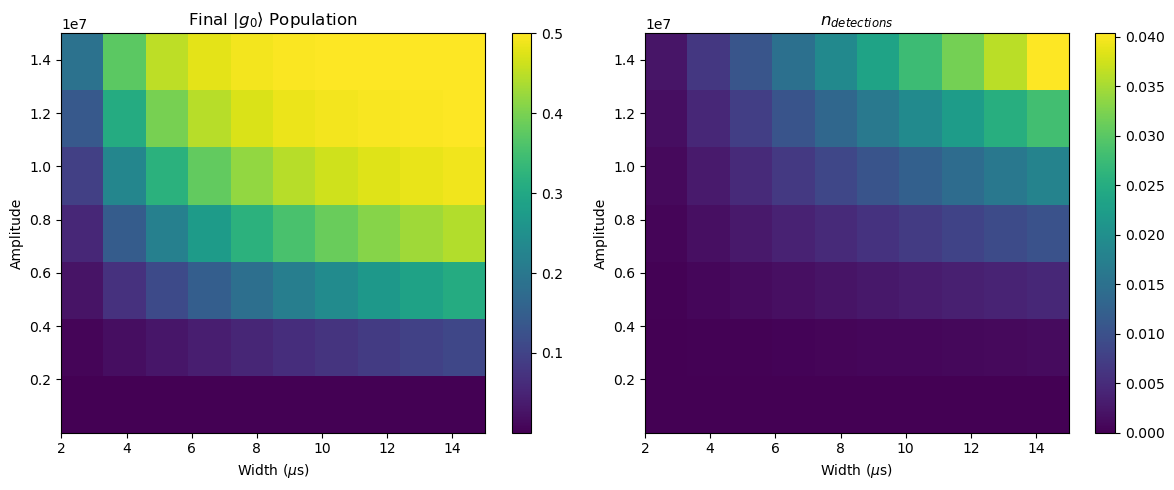

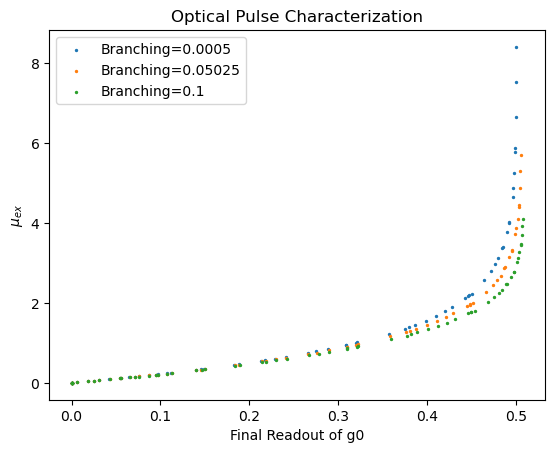

In [10]:

# Plot the results on subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot final_g0
im0 = axs[0].imshow(final_g0[:,:,0], aspect='auto', origin='lower', 
                    extent=[widths[0]*1e6, widths[-1]*1e6, amps[0], amps[-1]])
axs[0].set_title('Final $|g_0\\rangle$ Population')
axs[0].set_xlabel('Width ($\\mu$s)')
axs[0].set_ylabel('Amplitude')
fig.colorbar(im0, ax=axs[0])

# Plot mean_photon_number
im1 = axs[1].imshow(mean_zpl_counts[:,:,0], aspect='auto', origin='lower', 
                    extent=[widths[0]*1e6, widths[-1]*1e6, amps[0], amps[-1]])
axs[1].set_title('$n_{detections}$')
axs[1].set_xlabel('Width ($\\mu$s)')
axs[1].set_ylabel('Amplitude')
fig.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()

plt.figure()
for b_i, br in enumerate(branching_ratios):
    plt.scatter(
        final_g0[:, :, b_i].flatten(),
        mean_decay_number[:, :, b_i].flatten(),
        label=f'Branching={br}',
        s=2
    )
plt.ylabel("$\mu_{ex}$")
plt.xlabel("Final Readout of g0")
plt.title("Optical Pulse Characterization")
plt.legend()
plt.show()